# Bank Customer Churn Analysis

Customer churn is a major challenge for banks, as losing customers directly impacts long-term revenue and growth.

This project uses machine learning to predict which customers are likely to churn based on demographic and financial attributes. The goal is to identify high-risk customers early and support proactive retention strategies.

Through predictive modeling and risk segmentation, this analysis aims to provide both technical insights and actionable business understanding of customer churn behavior.

## Project Objective

The primary objectives of this project are:
* Predict which customers are likely to churn using machine learning models
* Identify key factors that influence customer churn
* Detect high-risk customers through churn probability analysis
* Improve early detection of churn using optimized probability thresholds

## Dataset Description

The dataset used in this project contains customer information from a bank, including demographic attributes, account details, and product usage indicators.

Key variables include:
* Credit Score
* Geography
* Gender
* Age
* Tenure
* Balance
* Number of Products
* Active Membership Status
* Estimated Salary
* Churn Status (Target Variable)

The target variable **Exited** indicates whether a customer has churned (1) or remained with the bank (0).

By combining data preprocessing, machine learning modeling, and post-model analysis, this project aims to provide both **technical insights and business-relevant interpretations of customer churn behavior**.

## Data Cleaning & Data Quality Check
An initial inspection of the dataset is performed to verify data quality before modeling.  
We check the dataset structure, confirm that no missing values exist, and ensure that all features are correctly formatted.

These checks help ensure that the dataset is reliable for downstream preprocessing and predictive modeling.

## Target Variable Distribution

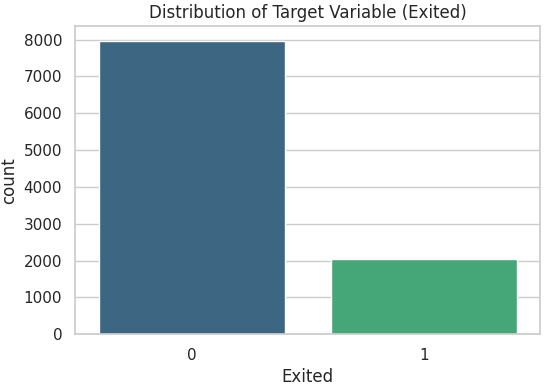

The target variable **Exited** represents whether a customer has churned (1) or remained with the bank (0).

From the dataset, **20.37% of customers have churned**, while **79.63% remain active**, indicating a moderately imbalanced dataset. This imbalance is common in churn prediction problems and must be considered during model evaluation.

To ensure consistent class representation during model training, a **stratified train-test split** will be used in the next step.


## Feature Masking

Certain variables are removed before modeling to prevent the model from learning patterns that are not related to customer behavior.

Columns such as **RowNumber**, **CustomerId**, and **Surname** serve only as identifiers and do not contain meaningful information for churn prediction. Keeping these variables could lead the model to memorize specific records rather than learn generalizable patterns.

Therefore, these identifier columns are excluded from the analysis.

## Feature Decoupling

To prepare the dataset for predictive modeling, the features and target variable are separated.

The feature matrix X contains all explanatory variables, while the target variable y represents the churn outcome (**Exited**). This separation allows machine learning models to learn the relationship between customer attributes and churn behavior.

## Predictive Modeling

Machine learning models were explored to predict customer churn based on the prepared features.
**Random Forest** and **XGBoost** were evaluated, with preliminary results showing **XGBoost** achieves slightly better performance, making it the champion model for further evaluation.

## Stratified Train-Test Split

The dataset is split into **8,000 training** and **2,000 testing** samples using stratified sampling based on the target variable Exited.
Churn proportion is maintained across both sets (**Training: 20.38%**, **Testing: 20.35%**) to ensure consistent class representation and reliable model evaluation.

## Model Benchmarking & Baseline Comparison

Multiple models were evaluated using 5-fold cross-validation:

* **Random Forest**: Avg ROC-AUC = 0.8626 ± 0.0092

* **XGBoost**: Avg ROC-AUC = 0.8651 ± 0.0117

Compared to the **baseline Logistic Regression** (AUC = 0.7748), **XGBoost improves predictive ability by 0.0883**, establishing it as the champion model for churn prediction.



## Final Model Performance

The final XGBoost model was evaluated on the **test set (2,000 samples)**, achieving a **ROC-AUC of 0.8630**.

Performance metrics by class:

* **Class 0 (Retention)**: Precision 0.88, Recall 0.97, F1-score 0.92

* **Class 1 (Churn)**: Precision 0.79, Recall 0.47, F1-score 0.59

Overall: **Accuracy 0.87**, **Macro F1 0.75**, **Weighted F1 0.85**.
The model demonstrates strong performance in predicting retention, with moderate recall for churn, highlighting the importance of further threshold tuning for early warning.

## Feature Importance

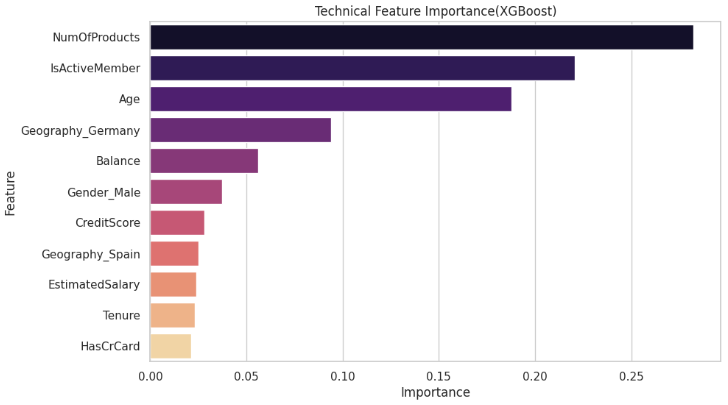

The final XGBoost model identifies the top drivers of churn as follows:

* **NumOfProducts** (0.283)
* **IsActiveMember** (0.221)
* **Age** (0.188)
* **Geography: Germany** (0.094)
* **Balance** (0.056)

These features highlight that customer engagement, age, location, and account balance are key factors influencing churn, providing actionable insights for retention strategies.

## Probability Generation & Top 20 High-Risk Customers

Predicted probabilities from the final XGBoost model are used to identify the **top 20 high-risk customers**.

**Averaged profile of these customers**:

* Age: 48.55
* Balance: 117,891.21
* NumOfProducts: 3.3
* IsActiveMember: 0.25
* EstimatedSalary: 111,500.75

**Geographical distribution**:

* Germany: 11
* France: 5
* Spain: 4

This highlights that mid-aged customers with multiple products, low activity, and high balances are most likely to churn, with Germany being the highest-risk region.

## Probability Threshold Strategy

The default probability threshold of 0.50 identifies **242 high-risk customers**.
By lowering the threshold to **0.35**, the model captures **390 customers**, increasing the churn recall rate from **46.68%** to **60.69%** — an improvement of **14.00%**.

This adjustment enhances early warning capability, allowing the bank to proactively target potential churners.

## Technical Metrics Summary

The final XGBoost model demonstrates strong predictive performance:

* **Test ROC-AUC**: 0.8630
* **Accuracy**: 0.87
* **Precision / Recall / F1**:
  * Class 0 (Retention): 0.88 / 0.97 / 0.92
  * Class 1 (Churn): 0.79 / 0.47 / 0.59
* **Macro F1**: 0.75, **Weighted F1**: 0.85

These metrics confirm the model's reliability in predicting retention and highlight opportunities to further improve churn recall via threshold adjustment.

## Technical Validation EDA

Three technical audit plots were analyzed to validate model behavior and feature distributions:

1. **Age Distribution by Churn**

* Retained customers (Class 0) concentrate around **20–40 years**, while churned customers (Class 1) show peaks in the **40–60 years** range, indicating mid-aged customers are more prone to churn.

2. **Product Count Impact**

* Customers with **fewer products** are mostly retained, whereas churned customers tend to have **multiple products**, highlighting engagement as a key driver.

3. **Model Confidence (Probability Distribution)**

* Predicted probabilities for retention (Class 0) cluster at **higher confidence** values, while churn (Class 1) probabilities are mostly **lower and dispersed**, confirming model's discriminative power.

These audits demonstrate that the model aligns with expected feature patterns and provides reliable churn predictions.

## Business Insights

* **High-risk segments**: Mid-aged customers (40–60 years), multiple products, low activity, high balance.
* **Geographical hotspots**: Germany accounts for the majority of churn among top 20 high-risk customers.
* **Engagement factor**: Active membership strongly reduces churn probability, highlighting the importance of retention programs.

These insights allow the bank to prioritize interventions and target the most vulnerable customers effectively.

## Business Structure Summary

* **Customer Segmentation**: Identify high-risk customers for proactive engagement.
* **Retention Programs**: Focus on mid-aged, multi-product, low-activity customers.
* **Regional Strategies**: Allocate resources to Germany, the highest-risk region.
* **Monitoring & Thresholds**: Use probability thresholds to capture additional potential churners early.

## Business Recommendations

1. **Targeted Campaigns**: Offer personalized incentives to high-risk segments (mid-aged, multiple products, inactive).
2. **Increase Engagement**: Encourage account activity and loyalty programs to reduce churn likelihood.
3. **Regional Focus**: Concentrate retention efforts in Germany, where churn risk is highest.
4. **Dynamic Thresholding**: Adjust churn probability thresholds to maximize early warning capture and resource efficiency.

## Conclusion

The predictive analysis using XGBoost identifies key drivers of customer churn, including **NumOfProducts**, **IsActiveMember**, **Age**, **Geography (Germany)**, and **Balance**.
The model demonstrates strong performance (**ROC-AUC 0.8630**, **Accuracy 0.87**, **Macro F1 0.75**) and effectively distinguishes high-risk segments.
By leveraging **probability threshold adjustments**, the bank can proactively target **mid-aged**, **multi-product**, **low-activity customers**, especially in Germany, enhancing retention programs and early warning capabilities.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder # (predict avg to 0 ,difference =1),prevent dummy variable trap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import warnings

warnings.filterwarnings('ignore')
#set theme
sns.set_theme(style="whitegrid")


/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv')

print(f"Data Shape:{df.shape}")

Data Shape:(10000, 14)


In [3]:
#sanity check(missing & repeated)
missing_values = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print("----Data Quality Audit----")
print(f"Missing Values:{missing_values[missing_values>0] if any (missing_values >0 )else 'None'}")
print(f"Duplicate Rows: {duplicate_count}")

----Data Quality Audit----
Missing Values:None
Duplicate Rows: 0


### Target Distribution

Churn Rate:20.37%
Retention Rate:79.63%


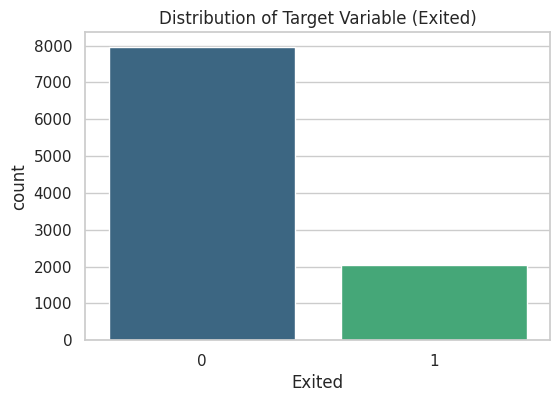

In [4]:
#churn and retention
churn_counts = df['Exited'].value_counts(normalize=True)
print(f"Churn Rate:{churn_counts[1]:.2%}")
print(f"Retention Rate:{churn_counts[0]:.2%}")

plt.figure(figsize=(6,4))
sns.countplot(x='Exited',data=df,palette='viridis')
plt.title('Distribution of Target Variable (Exited)')
plt.show()

### Feature Masking

In [5]:
#delete unnecessary information to prevent error and predict confusion
cols_to_drop = ['RowNumber','CustomerId','Surname']
df_sanitized = df.drop(columns=cols_to_drop)

print(f"Original Featured:{df.shape[1]}")
print(f"After Clean:{df_sanitized.shape[1]}")
print(f"Remained Featured:{df_sanitized.columns.tolist()}")

Original Featured:14
After Clean:11
Remained Featured:['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


### Feature Decoupling

In [6]:
#numerical
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
#Categories
cat_cols = ['Geography','Gender']
#target value
target_col = 'Exited'

### Predictive Modeling

In [7]:


preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(drop='first'),cat_cols)
    ]
)

### Stratified Train-Test Split

To check the accuracy and integrity of the model.
Test by the train set and test set. If test set is less, mean the model is cannot be trusted.

80 train, 20 test
set stratify = y to ensure the positive and negative data's percentage is the same

In [8]:

X = df_sanitized.drop(target_col, axis=1)
y = df_sanitized[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

print(f"Completed Cut：")
print(f"Train Set: {X_train.shape[0]}, Churn percent:{y_train.mean():.2%}")
print(f"Test Set:{X_test.shape[0]}, Churn percent:{y_test.mean():.2%}")

Completed Cut：
Train Set: 8000, Churn percent:20.38%
Test Set:2000, Churn percent:20.35%


### Model Benchmarking & Cross-Validation

Test two tabular data - random forest & XGBoost

Using 5-fold cross-validation

In [9]:


models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

cv_results = {}

print("5 fold cross-validation")

for name, model in models.items():
    full_pipeline = Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('classifier',model)
    ])
    scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = scores
    print(f"{name}: Avg ROC-AUC = {scores.mean():.4f}(standard deviation = {scores.std():.4f})")

5 fold cross-validation
RandomForest: Avg ROC-AUC = 0.8626(standard deviation = 0.0092)
XGBoost: Avg ROC-AUC = 0.8651(standard deviation = 0.0117)


### Final Model


In [10]:
best_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth = 6,
    random_state=42,
    use_label_encode=False,
    eval_metric='logloss'
)

#create final classifier's pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',best_model)
])

#full data with final analyse
final_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None,...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Baseline Model
Compare the baseline model and best model

In [11]:

y_probs = final_pipeline.predict_proba(X_test)[:,1] #predict churn rate

baseline_pipe = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(random_state=42))
])

baseline_pipe.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_test, baseline_pipe.predict_proba(X_test)[:, 1])

print(f"\n--- Baseline Check ---")
print(f"Logistic Regression (Baseline) AUC: {baseline_auc:.4f}")
print(f"XGBoost (Champion Model) AUC: {roc_auc_score(y_test, y_probs):.4f}")
print(f"Conclusion: XGBoost increase {(roc_auc_score(y_test, y_probs) - baseline_auc):.4f} of the prediction rate.")


--- Baseline Check ---
Logistic Regression (Baseline) AUC: 0.7748
XGBoost (Champion Model) AUC: 0.8630
Conclusion: XGBoost increase 0.0883 of the prediction rate.


### Feature Importance

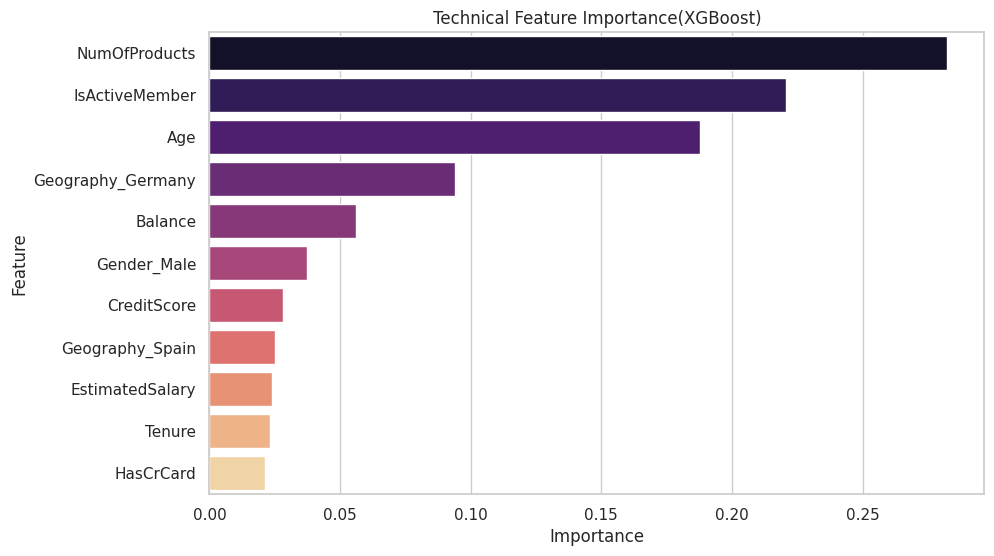

Top 5 main reason:
             Feature  Importance
4      NumOfProducts    0.282510
6     IsActiveMember    0.220684
1                Age    0.187692
8  Geography_Germany    0.093958
3            Balance    0.056106


In [12]:
#importance find out (to see top 5 important impact)
cat_encoder = final_pipeline.named_steps['preprocessor'].transformers_[1][1]
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + encoded_cat_cols

importances = final_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Technical Feature Importance(XGBoost)')
plt.show()

print("Top 5 main reason:")
print(feature_importance_df.head(5))

### Probability Generation & Export

Predict the churn and the churn percentage

In [13]:
#use test set to get an estimation
y_pred = final_pipeline.predict(X_test) # predict 0 /1 
y_probs = final_pipeline.predict_proba(X_test)[:,1] #predict churn rate

#combine the prediction to test set for further business insight
#create a table that include original feature, real tag and prediction rate
final_analysis_df = X_test.copy()
final_analysis_df['Actual_Exited']=y_test
final_analysis_df['Predicted_Exited'] = y_pred
final_analysis_df['Churn_Probability'] = y_probs

# detect high risk customer example
print("Top 20 High Risk Customer")
print(final_analysis_df.sort_values(by='Churn_Probability',ascending=False).head(20))

#export to csv
#final_analysis_df.to_csv('churn_predictions_with_probs.csv',index=False)
#print("\nEstimated result saved as 'churn_predictions_with_probs.csv'")

Top 20 High Risk Customer
      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
3549          675    France  Female   61       5   62055.17              3   
5922          555    France  Female   44       3  105770.70              3   
6831          469   Germany  Female   52       8  139493.25              3   
70            738   Germany    Male   58       2  133745.44              4   
9540          727   Germany    Male   46       3  115248.11              4   
5950          834   Germany  Female   57       8  112281.60              3   
8396          607    France  Female   48       4  112070.86              3   
5750          747   Germany    Male   37       9  135776.36              3   
3175          586    France  Female   35       7  164769.02              3   
6172          568   Germany    Male   43       5   87612.64              4   
6255          547   Germany    Male   55       4  111362.76              3   
871           629   Germany  Female   

### Top 20 High Risk Profile (AVG)

In [14]:
top_20_hr = final_analysis_df.sort_values(by='Churn_Probability', ascending=False).head(20)

#calculate avg of each profile
print("\n--- Top 20 Averaged Profile ---")
profile_summary = top_20_hr[['Age','Balance','NumOfProducts', 'IsActiveMember', 'EstimatedSalary']].mean()
print(profile_summary)

#check the high risk customer region
print("\n High Risk Customer's Region:")
print(top_20_hr['Geography'].value_counts())


--- Top 20 Averaged Profile ---
Age                    48.5500
Balance            117891.2060
NumOfProducts           3.3000
IsActiveMember          0.2500
EstimatedSalary    111500.7545
dtype: float64

 High Risk Customer's Region:
Geography
Germany    11
France      5
Spain       4
Name: count, dtype: int64


### Probability Threshold Strategy

In [15]:

business_threshold = 0.35
y_pred_business = (y_probs>=business_threshold).astype(int)

print(f"Threshold Change : {business_threshold}")
print(f"Default Thresold(Customer Catch): {sum(y_pred)}")
print(f"{business_threshold} (Customer Catch):{sum(y_pred_business)}")

default_recall= recall_score(y_test, y_pred)
business_recall = recall_score(y_test, y_pred_business)

print(f"\nDefault Recall: {default_recall:.2%}")
print(f"Business Recall: {business_recall:.2%}")
print(f"Churn Customer Recall Rate: {(business_recall - default_recall):.2%}")

Threshold Change : 0.35
Default Thresold(Customer Catch): 242
0.35 (Customer Catch):390

Default Recall: 46.68%
Business Recall: 60.69%
Churn Customer Recall Rate: 14.00%


### Technical Metrics

In [16]:
y_probs = final_pipeline.predict_proba(X_test)[:,1] #predict churn rate

print("Final Technical Metrics Report")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test,y_probs):.4f}")
print("\nClassifier Report:")
print(classification_report(y_test,y_pred))

Final Technical Metrics Report
Final Test ROC-AUC: 0.8630

Classifier Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



### EDA (Technical Validation EDA)

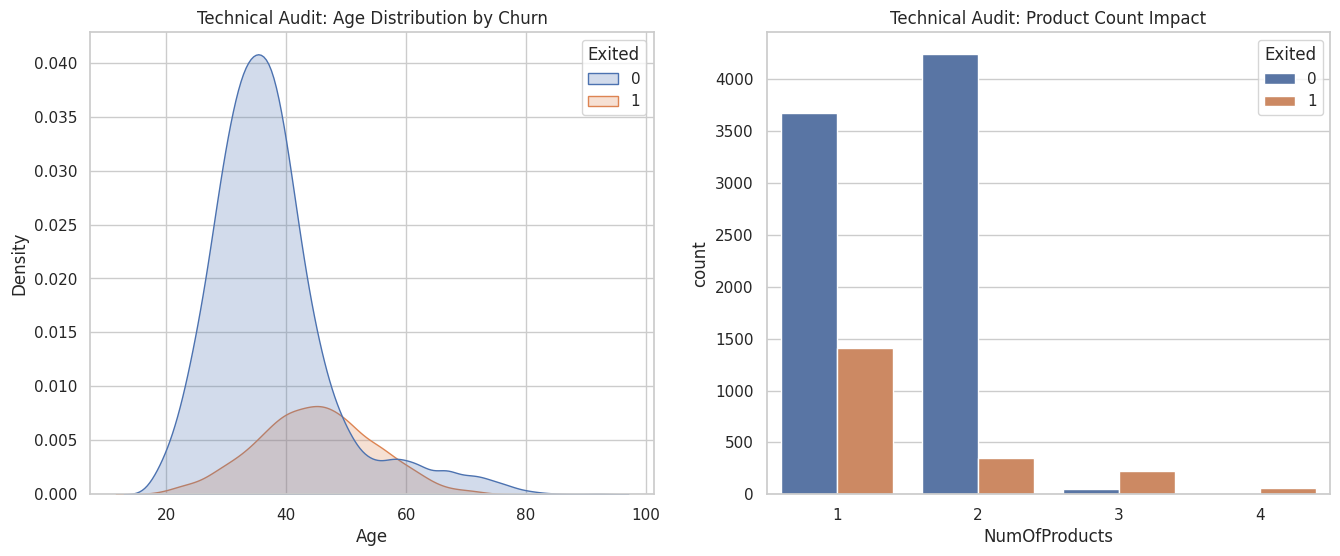

In [17]:
#use age and numofproducts
fig, ax = plt.subplots(1, 2, figsize=(16,6))

#age & churn
sns.kdeplot(data=df_sanitized, x='Age', hue='Exited', fill=True, ax=ax[0])
ax[0].set_title('Technical Audit: Age Distribution by Churn')

#product&churn
sns.countplot(data=df_sanitized, x='NumOfProducts',hue='Exited',ax=ax[1])
ax[1].set_title('Technical Audit: Product Count Impact')
plt.show()

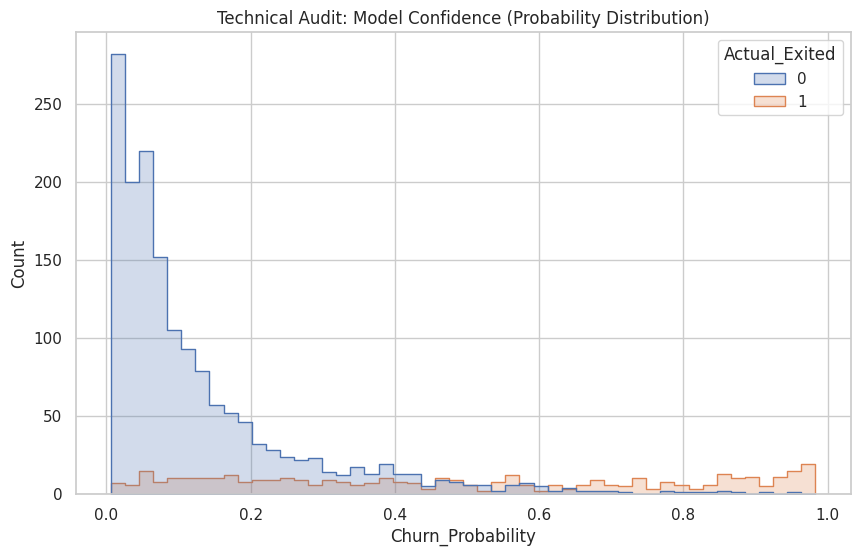

In [18]:
#probability calibration check
plt.figure(figsize=(10,6))
sns.histplot(final_analysis_df, x='Churn_Probability',hue='Actual_Exited',element="step",bins=50)
plt.title('Technical Audit: Model Confidence (Probability Distribution)')
plt.show()